In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df_cert = pd.read_csv('../data/certidoes_negativas_funai_v7.csv')
print("Certidões:", df_cert.shape)
print(df_cert[['Nome do Signatário', 'Militar ou Civil']].head())

Certidões: (78, 27)
          Nome do Signatário Militar ou Civil
0          Romero Jucá Filho            Civil
1          Romero Jucá Filho            Civil
2          Romero Jucá Filho            Civil
3  Nelson Marabuto Domingues            Civil
4      Gerson da Silva Alves            Civil


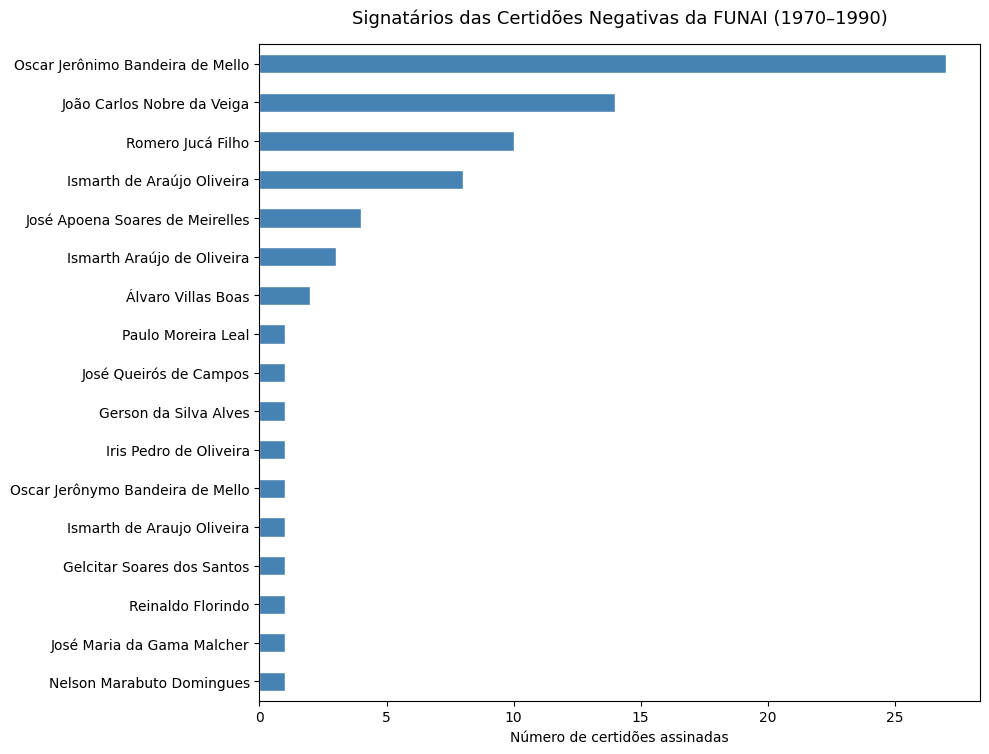

In [27]:
contagem_sign = (df_cert['Nome do Signatário']
                 .value_counts()
                 .sort_values(ascending=True))  # ascending p/ barh ficar em ordem crescente

plt.figure(figsize=(10, max(6, len(contagem_sign) * 0.45)))
contagem_sign.plot(kind='barh', color='steelblue', edgecolor='white')

plt.title('Signatários das Certidões Negativas da FUNAI (1970–1990)',
          fontsize=13, pad=15)
plt.xlabel('Número de certidões assinadas')
plt.ylabel('')
plt.tight_layout()

os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/05_signatarios.png', dpi=300)
plt.show()

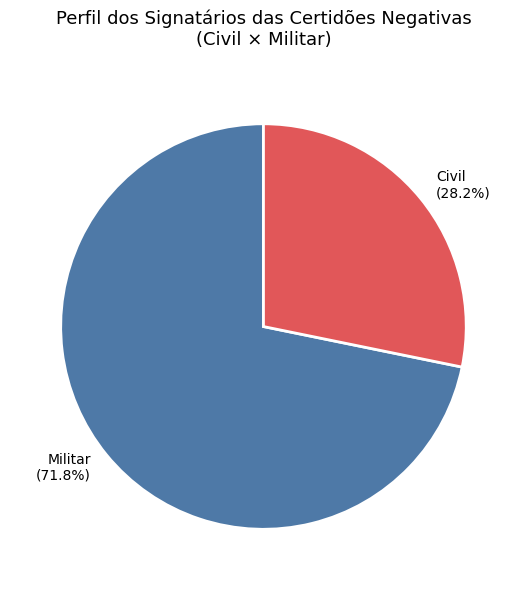

In [28]:
col_tipo = 'Militar ou Civil'

valores_tipo = df_cert[col_tipo].value_counts()
total_tipo = valores_tipo.sum()
percentuais_tipo = (valores_tipo / total_tipo * 100).round(1)

labels = [f'{k}\n({percentuais_tipo[k]}%)' for k in valores_tipo.index]
cores = ['#4e79a7', '#e15759']  # azul para civil, vermelho para militar

plt.figure(figsize=(6, 6))
plt.pie(valores_tipo,
        labels=labels,
        colors=cores,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Perfil dos Signatários das Certidões Negativas\n(Civil × Militar)',
          fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/06_civil_militar.png', dpi=300)
plt.show()

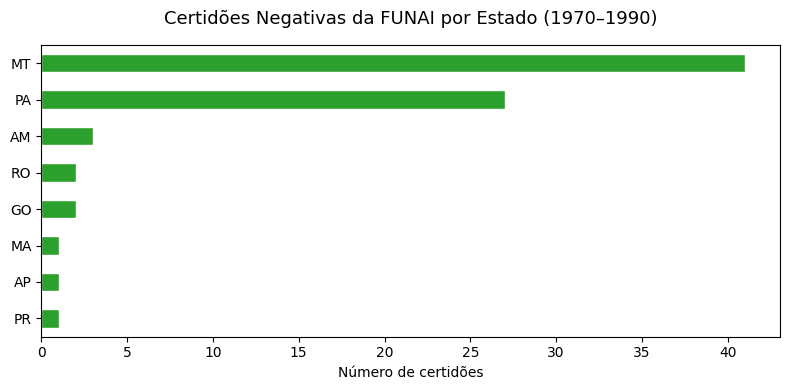

In [29]:
contagem_uf = (df_cert['UF da Área']
               .value_counts()
               .sort_values(ascending=True))

plt.figure(figsize=(8, max(4, len(contagem_uf) * 0.5)))
contagem_uf.plot(kind='barh', color='#2ca02c', edgecolor='white')

plt.title('Certidões Negativas da FUNAI por Estado (1970–1990)',
          fontsize=13, pad=15)
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/07_certidoes_por_uf.png', dpi=300)
plt.show()

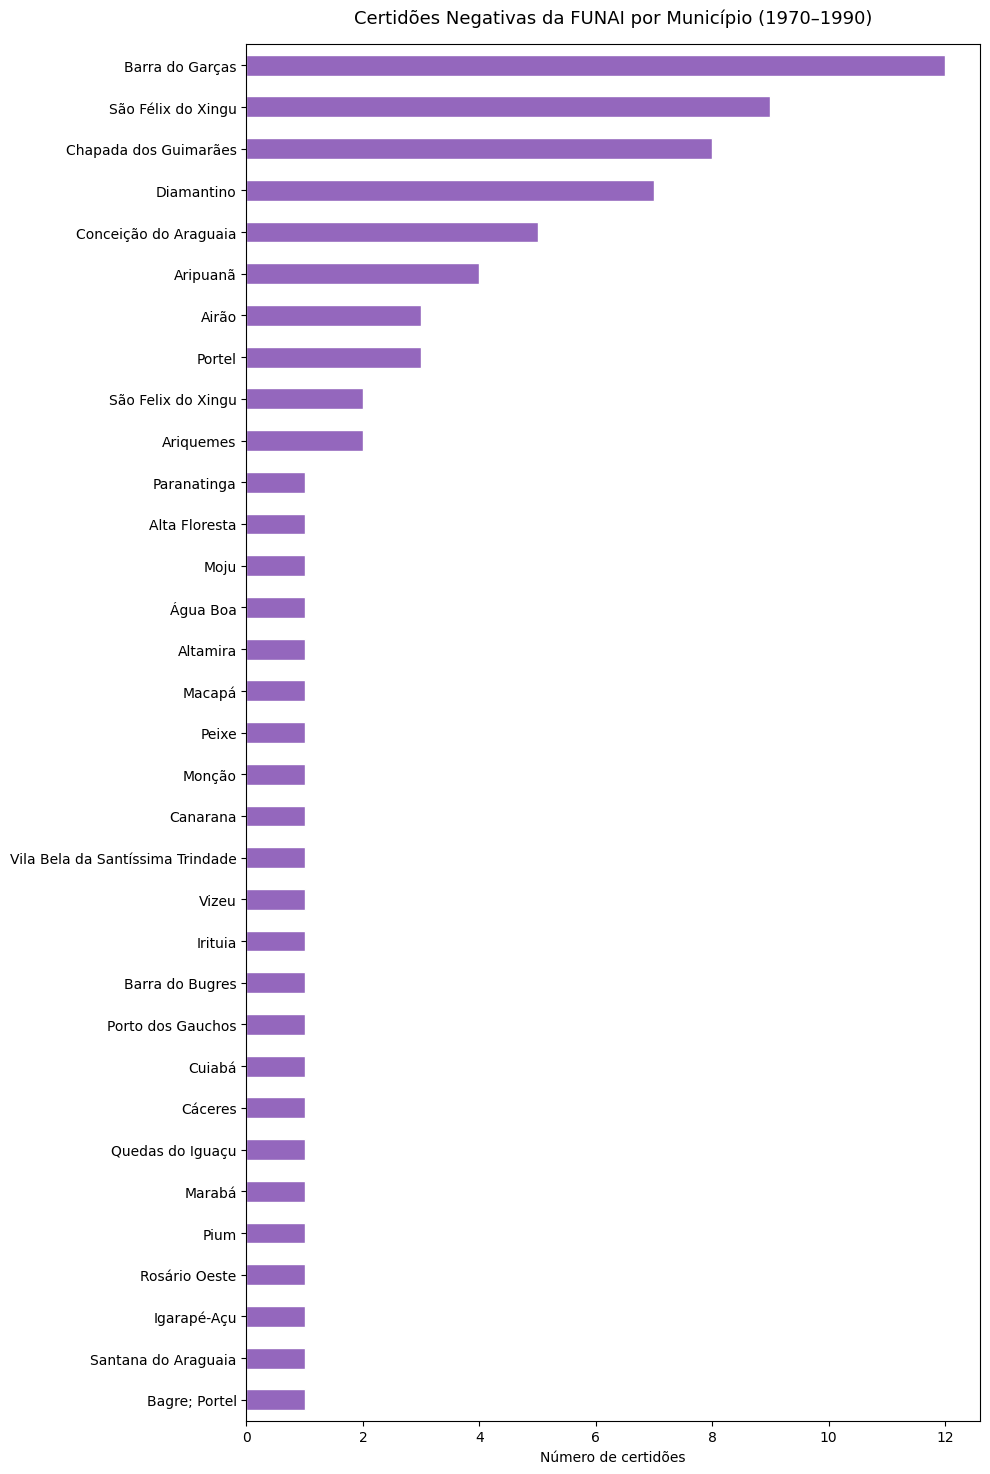

In [30]:
contagem_mun = (df_cert['Município']
                .value_counts()
                .sort_values(ascending=True))

plt.figure(figsize=(10, max(6, len(contagem_mun) * 0.45)))
contagem_mun.plot(kind='barh', color='#9467bd', edgecolor='white')

plt.title('Certidões Negativas da FUNAI por Município (1970–1990)',
          fontsize=13, pad=15)
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/08_certidoes_por_municipio.png', dpi=300)
plt.show()

###Análise temporal

In [31]:
print(df_cert['Data da Certidão'].head(10))

0    20/01/1987
1    08/04/1987
2    20/01/1987
3    26/02/1985
4    14/08/1985
5    11/09/1985
6    30/01/1986
7    24/03/1986
8    18/09/1985
9    29/05/1987
Name: Data da Certidão, dtype: str


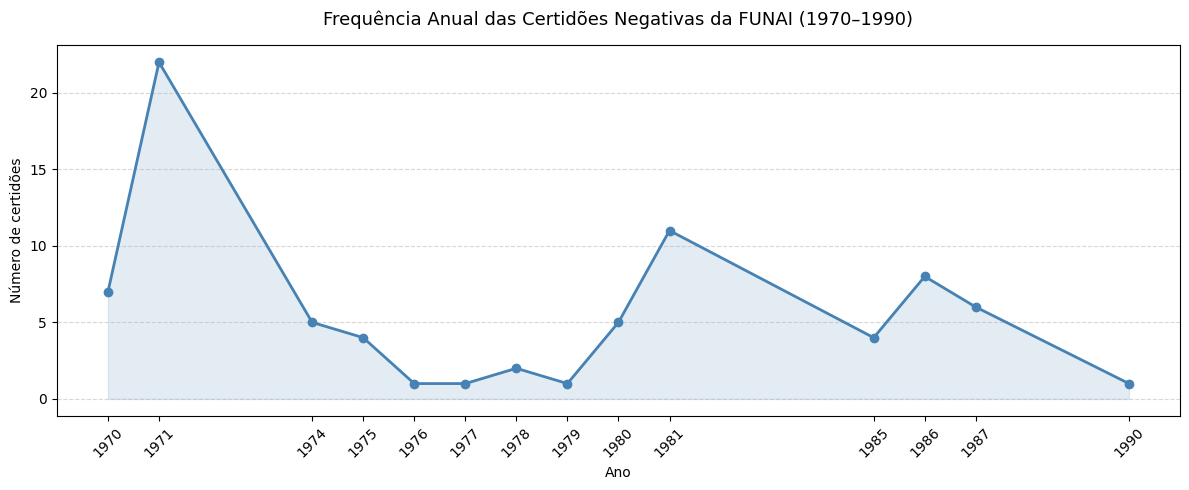

In [32]:
# Análise 1 — Frequência anual das certidões (1970–1990)

df_cert['Data da Certidão'] = pd.to_datetime(df_cert['Data da Certidão'], format='%d/%m/%Y')
df_cert['Ano'] = df_cert['Data da Certidão'].dt.year

freq_anual = df_cert['Ano'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(freq_anual.index, freq_anual.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(freq_anual.index, freq_anual.values, alpha=0.15, color='steelblue')

plt.title('Frequência Anual das Certidões Negativas da FUNAI (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('Número de certidões')
plt.xticks(freq_anual.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../outputs/figures/09_frequencia_anual_certidoes.png', dpi=300)
plt.show()

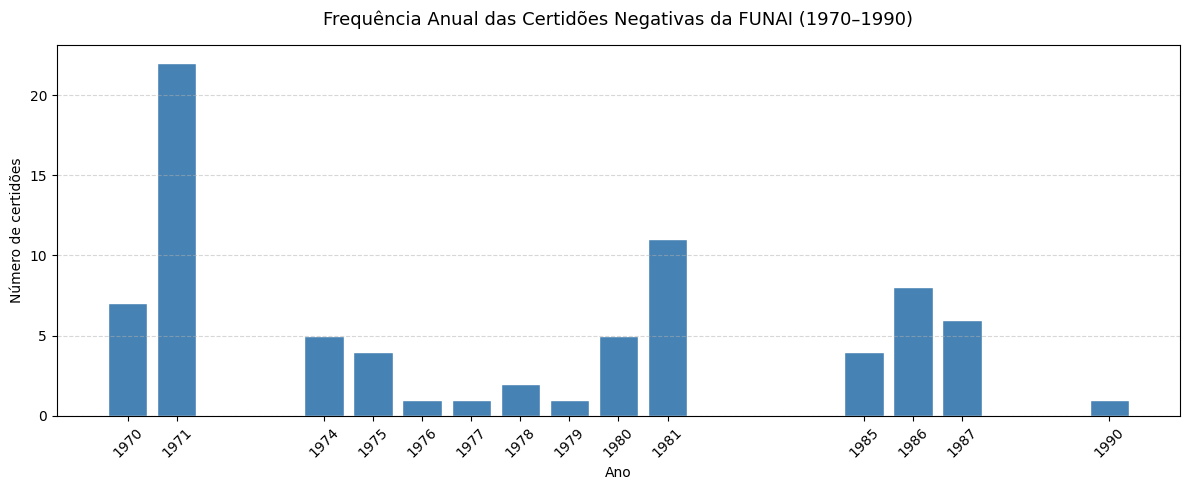

In [33]:
plt.figure(figsize=(12, 5))
plt.bar(freq_anual.index, freq_anual.values, color='steelblue', edgecolor='white')

plt.title('Frequência Anual das Certidões Negativas da FUNAI (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('Número de certidões')
plt.xticks(freq_anual.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../outputs/figures/09_frequencia_anual_certidoes.png', dpi=300)
plt.show()

In [34]:
print(df_cert['Nome do Signatário'].nunique())
print(df_cert['Nome do Signatário'].value_counts())

17
Nome do Signatário
Oscar Jerônimo Bandeira de Mello    27
João Carlos Nobre da Veiga          14
Romero Jucá Filho                   10
Ismarth de Araújo Oliveira           8
José Apoena Soares de Meirelles      4
Ismarth Araújo de Oliveira           3
Álvaro Villas Boas                   2
Nelson Marabuto Domingues            1
Gerson da Silva Alves                1
Iris Pedro de Oliveira               1
Oscar Jerônymo Bandeira de Mello     1
Ismarth de Araujo Oliveira           1
Gelcitar Soares dos Santos           1
Reinaldo Florindo                    1
José Maria da Gama Malcher           1
José Queirós de Campos               1
Paulo Moreira Leal                   1
Name: count, dtype: int64


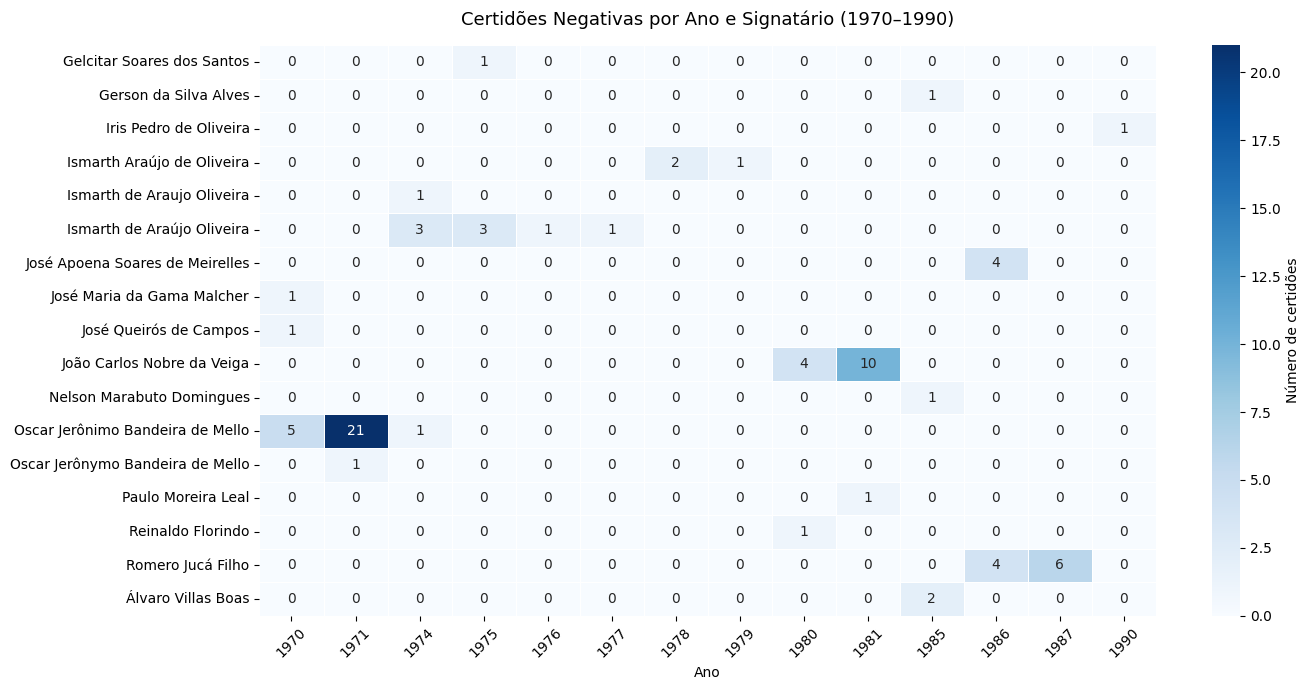

In [35]:
# Análise 2 — Heatmap ano × signatário

pivot = df_cert.groupby(['Ano', 'Nome do Signatário']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot.T,
            cmap='Blues',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Número de certidões'})

plt.title('Certidões Negativas por Ano e Signatário (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/figures/10_heatmap_ano_signatario.png', dpi=300)
plt.show()

In [36]:
print(df_cert['Nome do Signatário'].value_counts().to_string())

Nome do Signatário
Oscar Jerônimo Bandeira de Mello    27
João Carlos Nobre da Veiga          14
Romero Jucá Filho                   10
Ismarth de Araújo Oliveira           8
José Apoena Soares de Meirelles      4
Ismarth Araújo de Oliveira           3
Álvaro Villas Boas                   2
Nelson Marabuto Domingues            1
Gerson da Silva Alves                1
Iris Pedro de Oliveira               1
Oscar Jerônymo Bandeira de Mello     1
Ismarth de Araujo Oliveira           1
Gelcitar Soares dos Santos           1
Reinaldo Florindo                    1
José Maria da Gama Malcher           1
José Queirós de Campos               1
Paulo Moreira Leal                   1


In [37]:
correcoes = {
    'Oscar Jerônymo Bandeira de Mello': 'Oscar Jerônimo Bandeira de Mello',
    'Ismarth de Araújo Oliveira': 'Ismarth Araújo de Oliveira',
    'Ismarth de Araujo Oliveira': 'Ismarth Araújo de Oliveira'
}

df_cert['Nome do Signatário'] = df_cert['Nome do Signatário'].replace(correcoes)

print(df_cert['Nome do Signatário'].value_counts().to_string())

Nome do Signatário
Oscar Jerônimo Bandeira de Mello    28
João Carlos Nobre da Veiga          14
Ismarth Araújo de Oliveira          12
Romero Jucá Filho                   10
José Apoena Soares de Meirelles      4
Álvaro Villas Boas                   2
Nelson Marabuto Domingues            1
Gerson da Silva Alves                1
Iris Pedro de Oliveira               1
Gelcitar Soares dos Santos           1
Reinaldo Florindo                    1
José Maria da Gama Malcher           1
José Queirós de Campos               1
Paulo Moreira Leal                   1


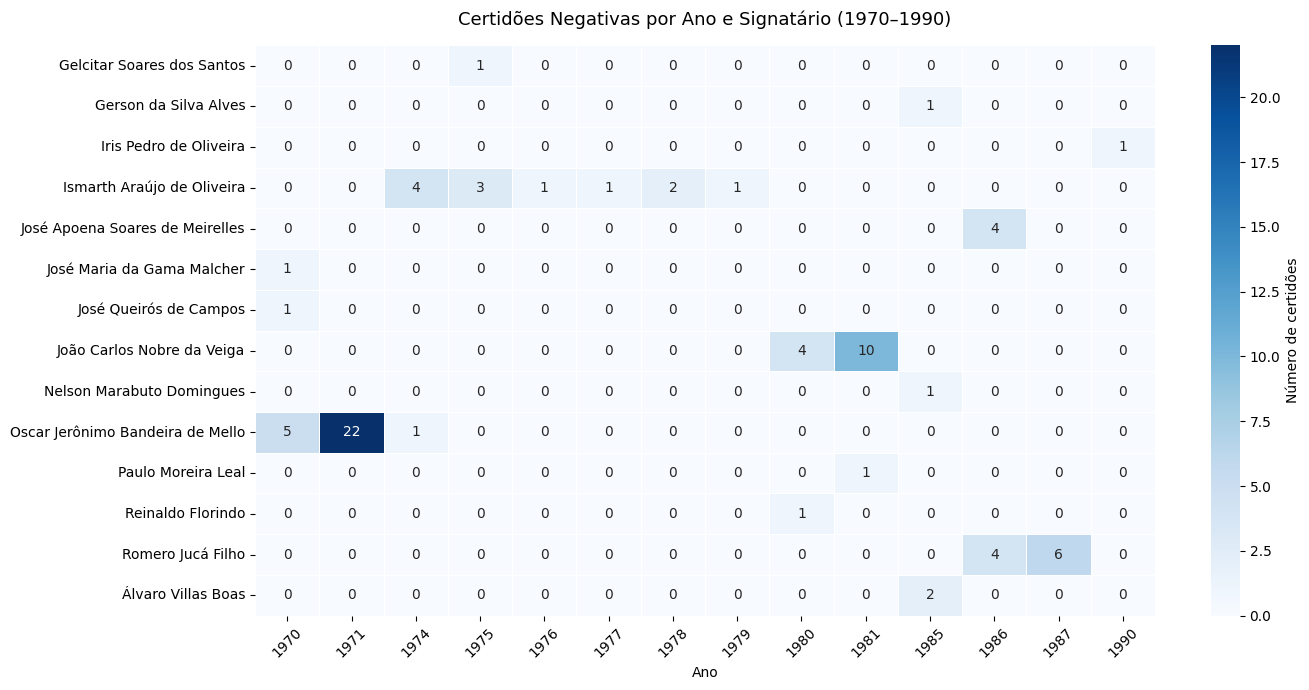

In [38]:
pivot = df_cert.groupby(['Ano', 'Nome do Signatário']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot.T,
            cmap='Blues',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Número de certidões'})

plt.title('Certidões Negativas por Ano e Signatário (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/figures/10_heatmap_ano_signatario.png', dpi=300)
plt.show()

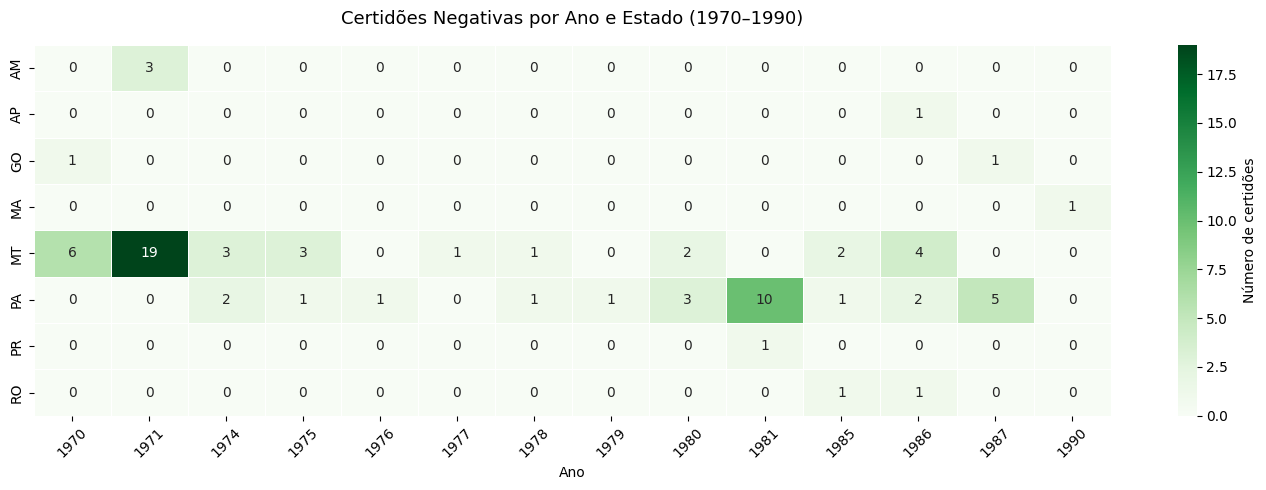

In [39]:
# Análise 3 — Heatmap ano × UF

pivot_uf = df_cert.groupby(['Ano', 'UF da Área']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_uf.T,
            cmap='Greens',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Número de certidões'})

plt.title('Certidões Negativas por Ano e Estado (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/figures/11_heatmap_ano_uf.png', dpi=300)
plt.show()

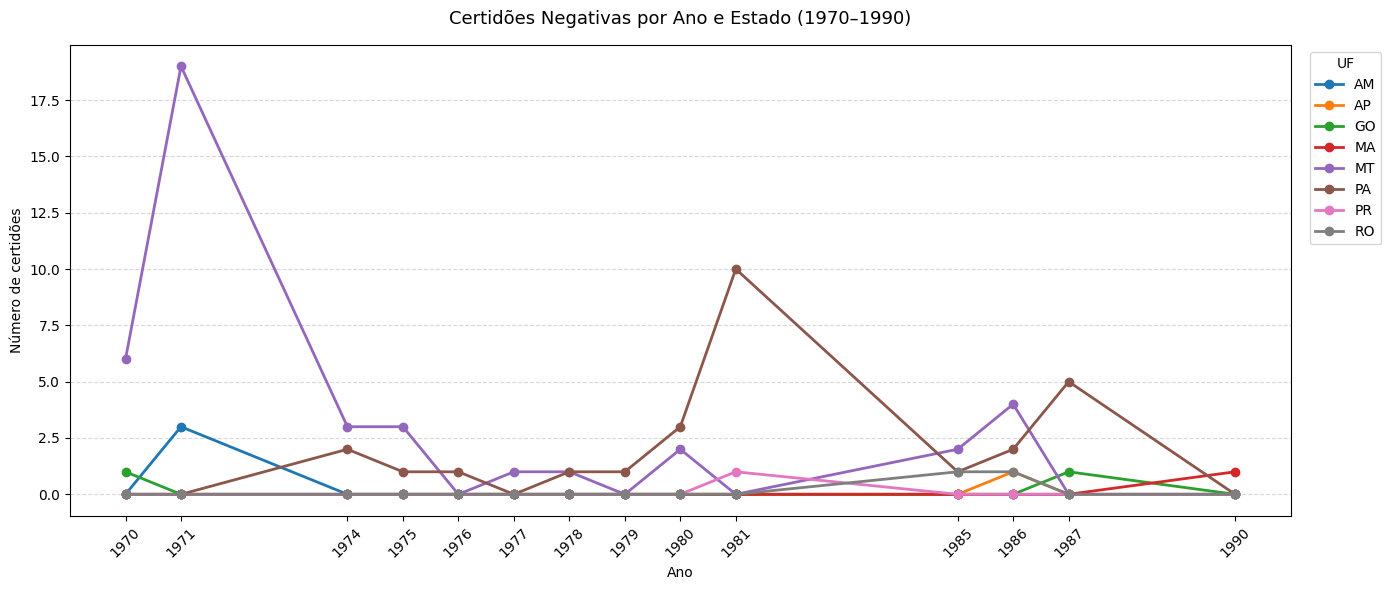

In [40]:
# Análise 3 — Linha múltipla ano × UF

pivot_uf = df_cert.groupby(['Ano', 'UF da Área']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
for uf in pivot_uf.columns:
    plt.plot(pivot_uf.index, pivot_uf[uf], marker='o', linewidth=2, label=uf)

plt.title('Certidões Negativas por Ano e Estado (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('Número de certidões')
plt.xticks(pivot_uf.index, rotation=45)
plt.legend(title='UF', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../outputs/figures/11_linhas_ano_uf.png', dpi=300)
plt.show()

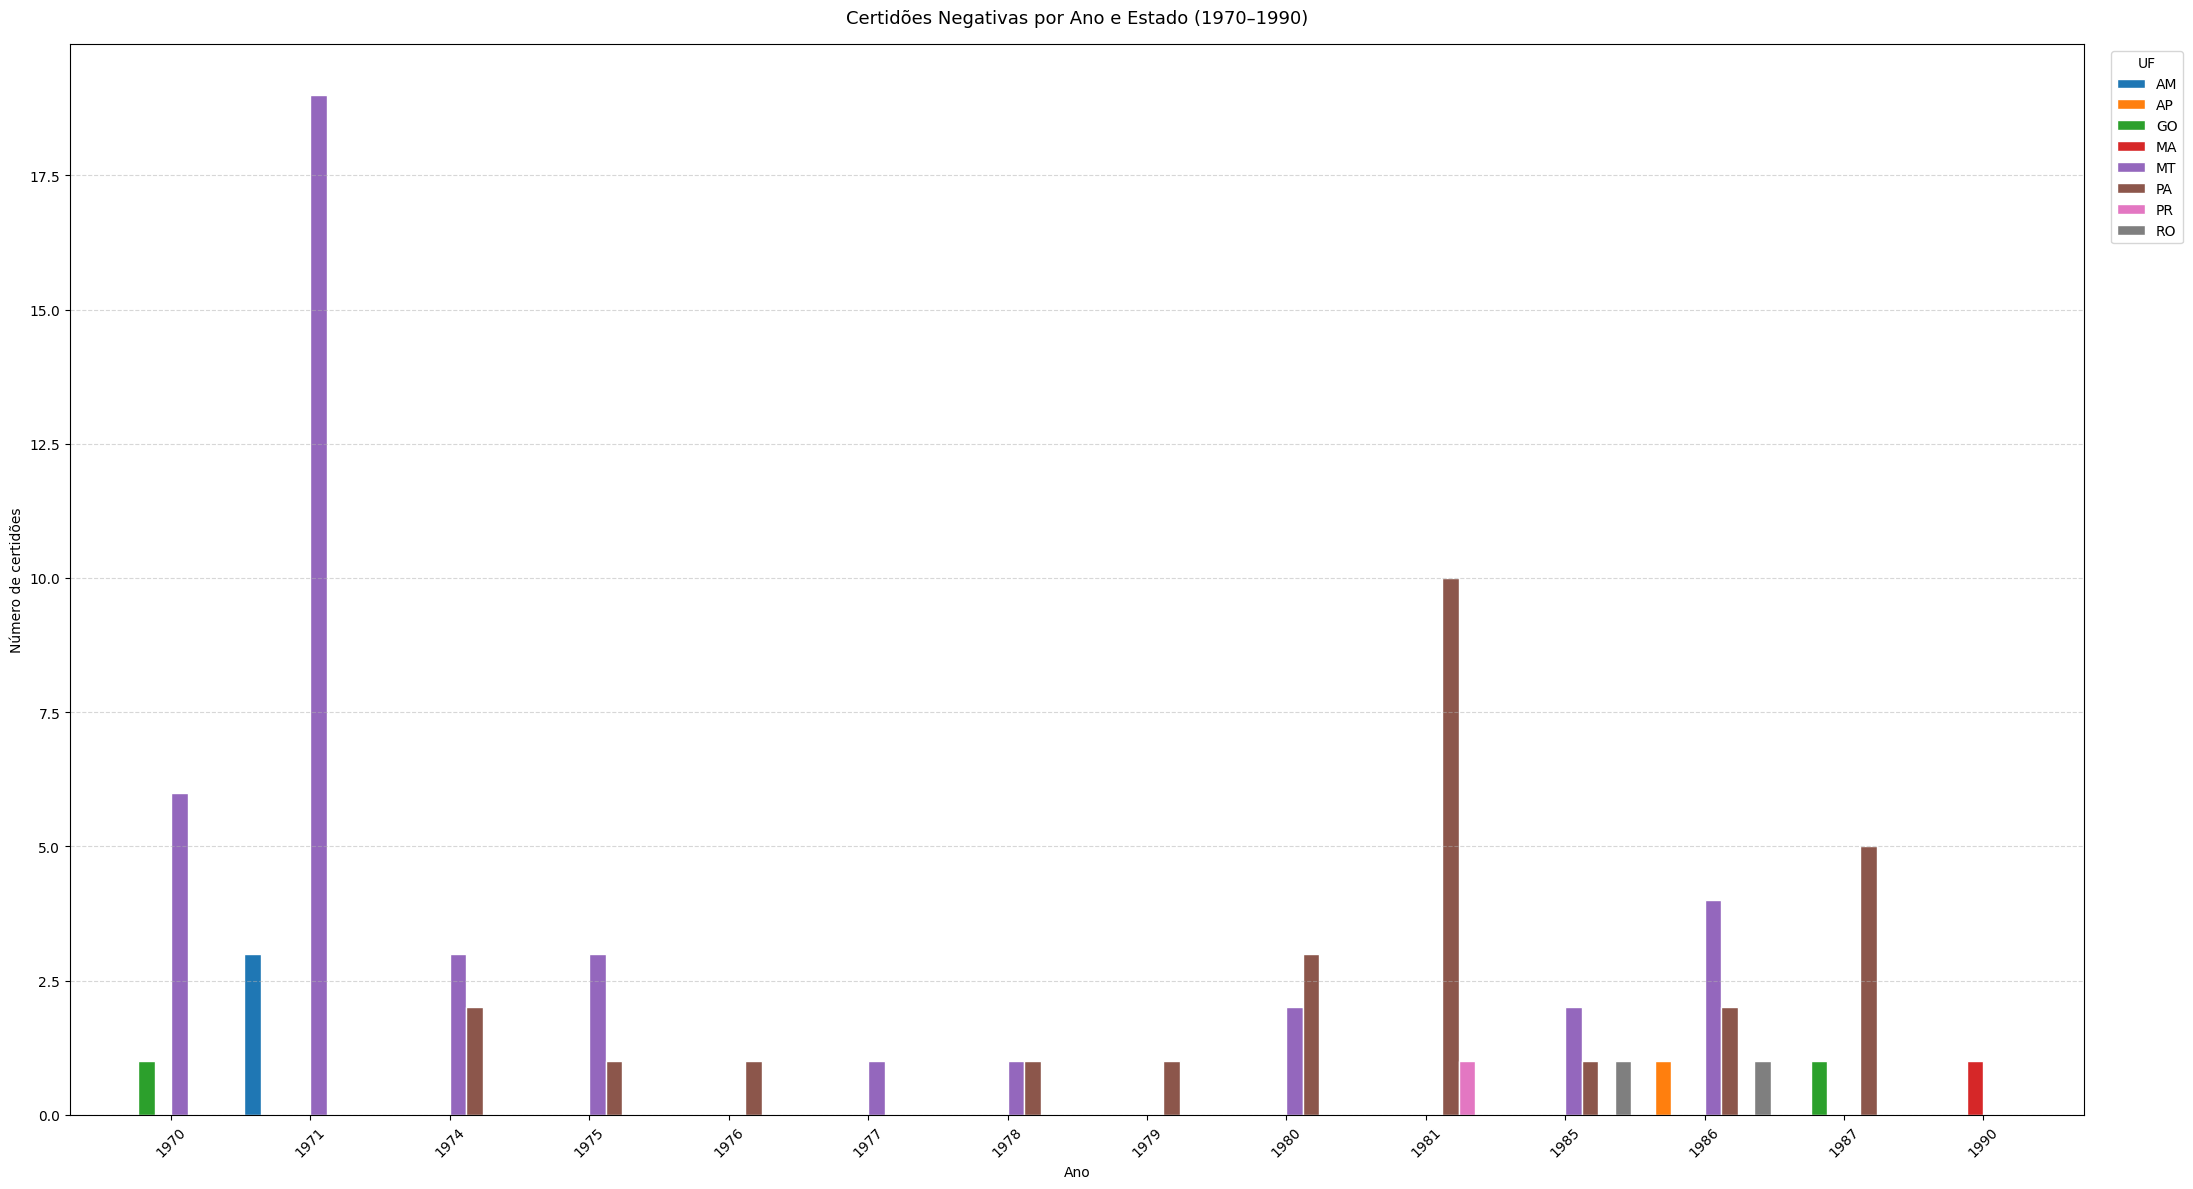

In [41]:
# Análise 3 — Barras verticais ano × UF

pivot_uf = df_cert.groupby(['Ano', 'UF da Área']).size().unstack(fill_value=0)

pivot_uf.plot(kind='bar', figsize=(22, 12), edgecolor='white', width=0.95)

plt.title('Certidões Negativas por Ano e Estado (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('Número de certidões')
plt.xticks(rotation=45)
plt.legend(title='UF', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../outputs/figures/11_barras_ano_uf.png', dpi=300)
plt.show()

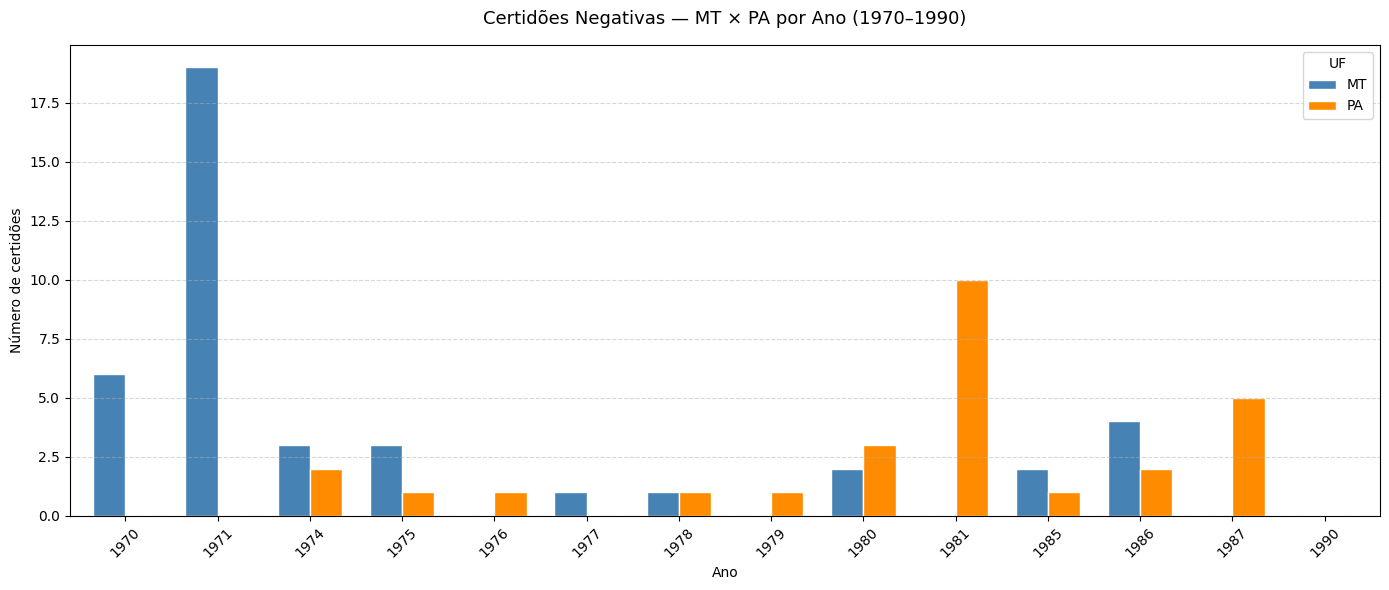

In [42]:
pivot_mt_pa = pivot_uf[['MT', 'PA']]

pivot_mt_pa.plot(kind='bar', figsize=(14, 6), edgecolor='white', width=0.7,
                 color=['steelblue', 'darkorange'])

plt.title('Certidões Negativas — MT × PA por Ano (1970–1990)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('Número de certidões')
plt.xticks(rotation=45)
plt.legend(title='UF')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../outputs/figures/12_mt_pa_por_ano.png', dpi=300)
plt.show()

In [43]:
df_cert['Década'] = (df_cert['Ano'] // 10) * 10

tabela_decada = df_cert[df_cert['UF da Área'].isin(['MT', 'PA'])]\
    .groupby(['Década', 'UF da Área']).size().unstack(fill_value=0)

print(tabela_decada)

UF da Área  MT  PA
Década            
1970        33   6
1980         8  21


###Análise temporal com as reportagens

In [44]:
print(df_rep['Data da publicação'].head(10))

0    07/11/1972
1    01/09/1976
2    01/10/1977
3    01/10/1977
4    07/10/1977
5    01/06/1978
6    01/08/1978
7    01/09/1978
8    25/10/1978
9    01/12/1978
Name: Data da publicação, dtype: str


In [45]:
df_rep = pd.read_csv('../data/reportagens_certidoes_negativas_v2.csv')
print(df_rep['Data da publicação'].head(10))

0    07/11/1972
1    01/09/1976
2    01/10/1977
3    01/10/1977
4    07/10/1977
5    01/06/1978
6    01/08/1978
7    01/09/1978
8    25/10/1978
9    01/12/1978
Name: Data da publicação, dtype: str


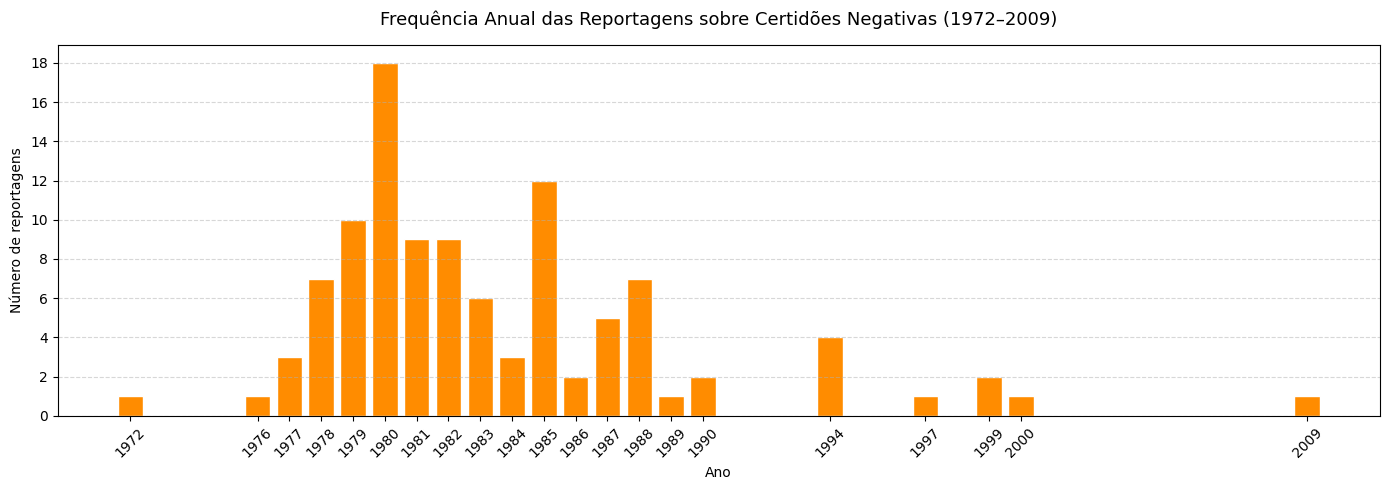

In [47]:
# Frequência anual das reportagens (1972–2009)

df_rep['Data da publicação'] = pd.to_datetime(df_rep['Data da publicação'], format='%d/%m/%Y')
df_rep['Ano'] = df_rep['Data da publicação'].dt.year

freq_anual_rep = df_rep['Ano'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(freq_anual_rep.index, freq_anual_rep.values, color='darkorange', edgecolor='white')

plt.title('Frequência Anual das Reportagens sobre Certidões Negativas (1972–2009)',
          fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('Número de reportagens')
plt.xticks(freq_anual_rep.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()

plt.savefig('../outputs/figures/13_frequencia_anual_reportagens.png', dpi=300)
plt.show()

In [48]:
print(df_rep.columns.tolist())

['Nome do Jornal ou Revista', 'Estado da federação da publicação', 'Título do texto', 'Data da publicação', 'Nome do autor do texto', 'Povo indígena mencionado', 'TI Mencionada (entre parênteses o nome atual)', 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)', 'Nomes de empresas, fazendas ou indivíduos mencionados', 'Entrevista algum indígena?', 'Qual o nome do indígena entrevistado?', 'Há não-indígena entrevistado?', 'Nome do não-indígena entrevistado', 'Cargo ou profissão do não-indígena entrevistado', 'Se houver, evento mencionado (violência, crimes, etc)', 'Link da notícia', 'Ano']


In [49]:
print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Nome do Jornal ou Revista
A Crítica                                                     8
O Estado de São Paulo                                         6
Aconteceu especial no. 18                                     5
Povos Indígenas no Brasil                                     5
Diário de Cuiabá                                              3
Porantim Ano III No. 22                                       3
Folha de São Paulo                                            3
Revista Agroeste                                              3
A Notícia                                                     3
Aconteceu especial no. 12                                     3
Aconteceu especial no. 15                                     3
Boletim do CIMI ano 6 no. 41                                  2
Jornal do Brasil                                              2
Porantim Ano III No. 24                                       2
Aconteceu (ISA) - Volume 8                                    2
Boletim do CIM

In [50]:
correcoes_rep = {
    'Jornal A Crítica': 'A Crítica',
    'Estado de São Paulo': 'O Estado de São Paulo',
    'Porantim Ano III No. 22': 'Porantim',
    'Porantim Ano III No. 24': 'Porantim',
    'Porantim no. 4': 'Porantim',
    'Porantim Ano XXXI No. 317': 'Porantim',
    'Aconteceu especial no. 18': 'Aconteceu (ISA)',
    'Aconteceu especial no. 12': 'Aconteceu (ISA)',
    'Aconteceu especial no. 15': 'Aconteceu (ISA)',
    'Aconteceu (ISA) - Volume 8': 'Aconteceu (ISA)',
    'Aconteceu especial': 'Aconteceu (ISA)',
    'Boletim do CIMI ano 6 no. 41': 'Boletim do CIMI',
    'Boletim do CIMI no. 31': 'Boletim do CIMI',
    'Boletim do CIMI ano 7 no. 52': 'Boletim do CIMI',
    'CIMI - Norte I (não consta título)': 'Boletim do CIMI',
    'Coleção CIMI Norte I': 'Boletim do CIMI',
    'Varadouro Ano I No. 10': 'Varadouro',
    'Varadouro Ano II No. 13': 'Varadouro',
}

df_rep['Nome do Jornal ou Revista'] = df_rep['Nome do Jornal ou Revista'].replace(correcoes_rep)

print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Nome do Jornal ou Revista
Aconteceu (ISA)                                               14
A Crítica                                                      9
O Estado de São Paulo                                          7
Porantim                                                       7
Boletim do CIMI                                                6
Povos Indígenas no Brasil                                      5
Diário de Cuiabá                                               3
Folha de São Paulo                                             3
Revista Agroeste                                               3
A Notícia                                                      3
Varadouro                                                      2
Jornal do Brasil                                               2
Nimuendajú - Boletim da Comissão Pró-Índio Ano 1, no.1         1
Porantim Ano II No. 9                                          1
Varadouro Ano IINo. 16                                         1

In [51]:
df_rep = pd.read_csv('../data/reportagens_certidoes_negativas_v3.csv')
print("Reportagens:", df_rep.shape)
print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Reportagens: (105, 16)
Nome do Jornal ou Revista
A Crítica                                                     9
Folha de São Paulo                                            9
O Estado de São Paulo                                         7
Diário de Cuiabá                                              5
Aconteceu especial no. 18                                     4
A Notícia                                                     3
Diário Oficial da União                                       3
Correio Braziliense                                           3
Jornal do Brasil                                              3
Revista Agroeste                                              3
Correio do Povo                                               2
Aconteceu (ISA) - Volume 8                                    2
Boletim do CIMI ano 6 no. 41                                  2
Porantim Ano III No. 22                                       2
Porantim Ano III No. 24                                

In [52]:
correcoes_rep = {
    'Jornal A Crítica': 'A Crítica',
    'Estado de São Paulo': 'O Estado de São Paulo',
    'Porantim Ano III No. 22': 'Porantim',
    'Porantim Ano III No. 24': 'Porantim',
    'Porantim no. 4': 'Porantim',
    'Porantim Ano XXXI No. 317': 'Porantim',
    'Aconteceu especial no. 18': 'Aconteceu (ISA)',
    'Aconteceu especial no. 12': 'Aconteceu (ISA)',
    'Aconteceu especial no. 15': 'Aconteceu (ISA)',
    'Aconteceu (ISA) - Volume 8': 'Aconteceu (ISA)',
    'Aconteceu especial': 'Aconteceu (ISA)',
    'Boletim do CIMI ano 6 no. 41': 'Boletim do CIMI',
    'Boletim do CIMI no. 31': 'Boletim do CIMI',
    'Boletim do CIMI ano 7 no. 52': 'Boletim do CIMI',
    'CIMI - Norte I (não consta título)': 'Boletim do CIMI',
    'Coleção CIMI Norte I': 'Boletim do CIMI',
    'Varadouro Ano I No. 10': 'Varadouro',
    'Varadouro Ano II No. 13': 'Varadouro',
}

df_rep['Nome do Jornal ou Revista'] = df_rep['Nome do Jornal ou Revista'].replace(correcoes_rep)

print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Nome do Jornal ou Revista
A Crítica                                                     10
Folha de São Paulo                                             9
Aconteceu (ISA)                                                8
O Estado de São Paulo                                          8
Boletim do CIMI                                                6
Diário de Cuiabá                                               5
Porantim                                                       5
A Notícia                                                      3
Diário Oficial da União                                        3
Correio Braziliense                                            3
Jornal do Brasil                                               3
Revista Agroeste                                               3
Correio do Povo                                                2
Povos Indígenas no Brasil                                      2
Varadouro                                                      2

In [53]:
correcoes_rep = {
    # Aconteceu (ISA)
    'Aconteceu - Volume 8': 'Aconteceu (ISA)',
    'Aconteceu (ISA) - volume 8': 'Aconteceu (ISA)',
    'Aconteceu especial no. 17 - 1985-1986': 'Aconteceu (ISA)',
    'Aconteceu especial no. 17 1985-1986': 'Aconteceu (ISA)',
    # Amazonas em Tempo
    'Am em Tempo': 'Amazonas em Tempo',
    # Varadouro
    'Varadouro Ano IINo. 16': 'Varadouro',
    # Terra Indígena
    'Terra Indígena - Boletim do G.E.I. Kurumim - Ano IV No. 40': 'Terra Indígena',
    'Terra Indígena Ano VI No. 51': 'Terra Indígena',
}

df_rep['Nome do Jornal ou Revista'] = df_rep['Nome do Jornal ou Revista'].replace(correcoes_rep)

print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Nome do Jornal ou Revista
Aconteceu (ISA)                                              12
A Crítica                                                    10
Folha de São Paulo                                            9
O Estado de São Paulo                                         8
Boletim do CIMI                                               6
Diário de Cuiabá                                              5
Porantim                                                      5
A Notícia                                                     3
Diário Oficial da União                                       3
Correio Braziliense                                           3
Jornal do Brasil                                              3
Revista Agroeste                                              3
Varadouro                                                     3
Correio do Povo                                               2
Amazonas em Tempo                                             2
Povos Indígena

In [54]:
correcoes_rep2 = {
    # Porantim
    'Porantim Ano VIII No. 80': 'Porantim',
    'Porantim Ano VIII No. 82': 'Porantim',
    # Gazeta (possível erro de digitação)
    'Gazita': 'Gazeta de Notícias',
}

df_rep['Nome do Jornal ou Revista'] = df_rep['Nome do Jornal ou Revista'].replace(correcoes_rep2)

print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Nome do Jornal ou Revista
Aconteceu (ISA)                                              12
A Crítica                                                    10
Folha de São Paulo                                            9
O Estado de São Paulo                                         8
Porantim                                                      7
Boletim do CIMI                                               6
Diário de Cuiabá                                              5
A Notícia                                                     3
Diário Oficial da União                                       3
Correio Braziliense                                           3
Jornal do Brasil                                              3
Revista Agroeste                                              3
Varadouro                                                     3
Correio do Povo                                               2
Gazeta de Notícias                                            2
Amazonas em Te

In [55]:
correcoes_rep3 = {
    'Porantim Ano V No. 49': 'Porantim',
}

df_rep['Nome do Jornal ou Revista'] = df_rep['Nome do Jornal ou Revista'].replace(correcoes_rep3)

print(df_rep['Nome do Jornal ou Revista'].value_counts().to_string())

Nome do Jornal ou Revista
Aconteceu (ISA)                                              12
A Crítica                                                    10
Folha de São Paulo                                            9
O Estado de São Paulo                                         8
Porantim                                                      8
Boletim do CIMI                                               6
Diário de Cuiabá                                              5
A Notícia                                                     3
Diário Oficial da União                                       3
Correio Braziliense                                           3
Jornal do Brasil                                              3
Revista Agroeste                                              3
Varadouro                                                     3
Correio do Povo                                               2
Gazeta de Notícias                                            2
Amazonas em Te

In [56]:
for nome in sorted(df_rep['Nome do Jornal ou Revista'].unique()):
    print(nome)

A Crítica
A Notícia
Aconteceu (ISA)
Amazonas em Tempo
Boletim Mensal - Grupo de Estudos Indígenas Kurumim no.10
Boletim do CIMI
Boletim do GTME ano IV no. 13
Brasil Norte
Correio Braziliense
Correio do Povo
Diário Oficial da União
Diário de Cuiabá
Folha da Tarde
Folha de São Paulo
Gazeta de Notícias
Jornal do Brasil
Jornal do Comércio
Nimuendajú - Boletim da Comissão Pró-Índio Ano 1, no.1
O Estado de São Paulo
O Estado do Amazonas
O Liberal
O Mensageiro n.115
O Rio Branco
Porantim
Porantim Ano II No. 9
Porantim Ano III No. 26
Porantim Ano IV No. 29
Porantim Ano IV No. 32
Porantim Ano IV No. 37
Porantim Ano IV No. 38
Porantim Ano IX No. 97
Povos Indígenas no Brasil
Revista Agroeste
Terra Indígena
Tribuna da Imprensa
Tribuna de Roraima
Varadouro


In [57]:
correcoes_porantim = {
    'Porantim Ano II No. 9': 'Porantim',
    'Porantim Ano III No. 26': 'Porantim',
    'Porantim Ano IV No. 29': 'Porantim',
    'Porantim Ano IV No. 32': 'Porantim',
    'Porantim Ano IV No. 37': 'Porantim',
    'Porantim Ano IV No. 38': 'Porantim',
    'Porantim Ano IX No. 97': 'Porantim',
}

df_rep['Nome do Jornal ou Revista'] = df_rep['Nome do Jornal ou Revista'].replace(correcoes_porantim)

# Verificar — deve retornar lista limpa
for nome in sorted(df_rep['Nome do Jornal ou Revista'].unique()):
    print(nome)

A Crítica
A Notícia
Aconteceu (ISA)
Amazonas em Tempo
Boletim Mensal - Grupo de Estudos Indígenas Kurumim no.10
Boletim do CIMI
Boletim do GTME ano IV no. 13
Brasil Norte
Correio Braziliense
Correio do Povo
Diário Oficial da União
Diário de Cuiabá
Folha da Tarde
Folha de São Paulo
Gazeta de Notícias
Jornal do Brasil
Jornal do Comércio
Nimuendajú - Boletim da Comissão Pró-Índio Ano 1, no.1
O Estado de São Paulo
O Estado do Amazonas
O Liberal
O Mensageiro n.115
O Rio Branco
Porantim
Povos Indígenas no Brasil
Revista Agroeste
Terra Indígena
Tribuna da Imprensa
Tribuna de Roraima
Varadouro


In [58]:
df_rep.to_csv('../data/reportagens_certidoes_negativas_v4.csv', index=False)
print("Salvo!")

Salvo!


In [60]:
df_rep['Data da publicação'] = pd.to_datetime(df_rep['Data da publicação'], format='%d/%m/%Y')
df_rep['Ano'] = df_rep['Data da publicação'].dt.year

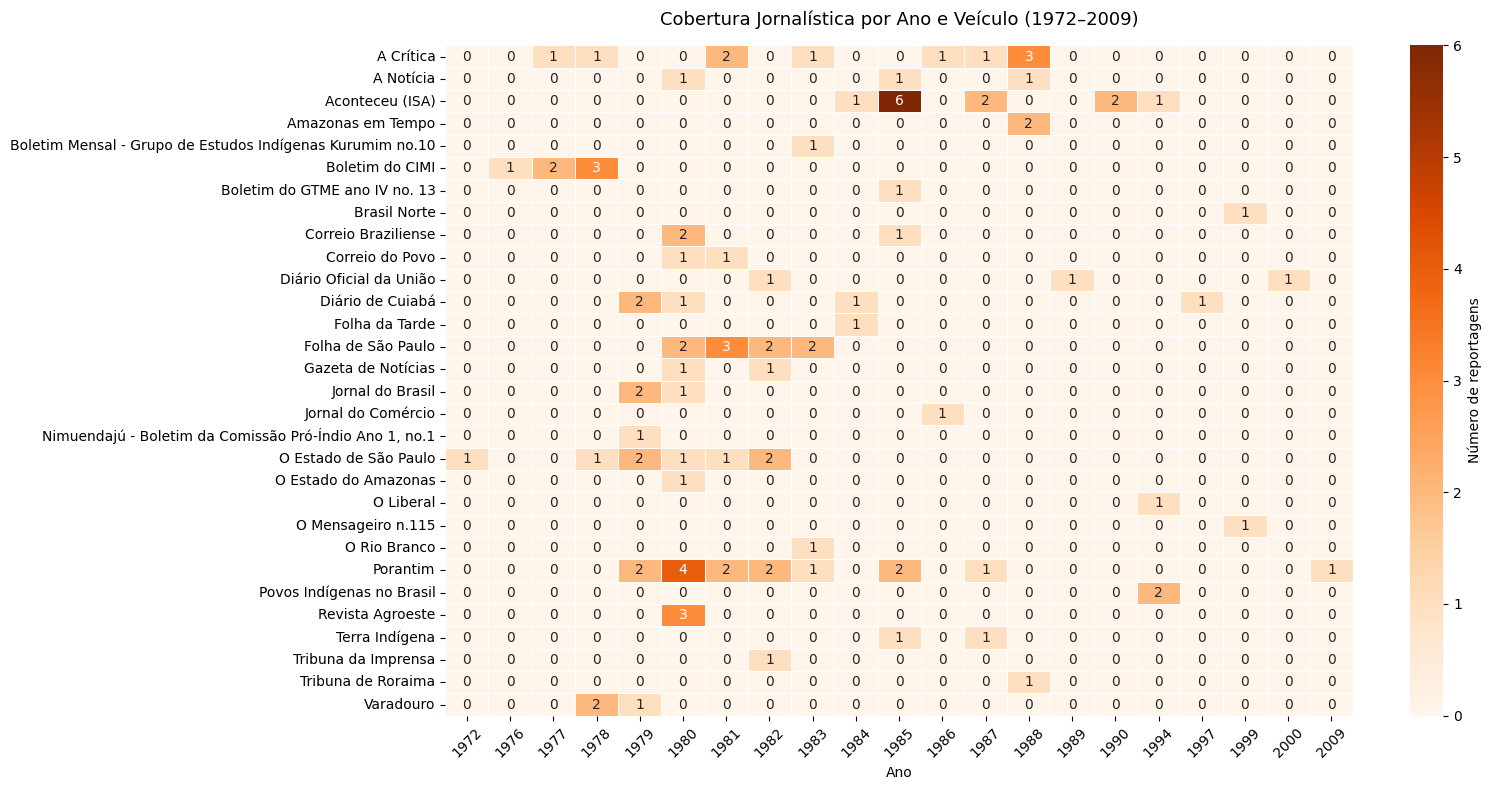

In [62]:
# Cobertura por ano × jornal/revista

pivot_rep = df_rep.groupby(['Ano', 'Nome do Jornal ou Revista']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_rep.T,
            cmap='Oranges',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Número de reportagens'})

plt.title('Cobertura Jornalística por Ano e Veículo (1972–2009)', fontsize=13, pad=15)
plt.xlabel('Ano')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/figures/14_heatmap_ano_veiculo.png', dpi=300)
plt.show()

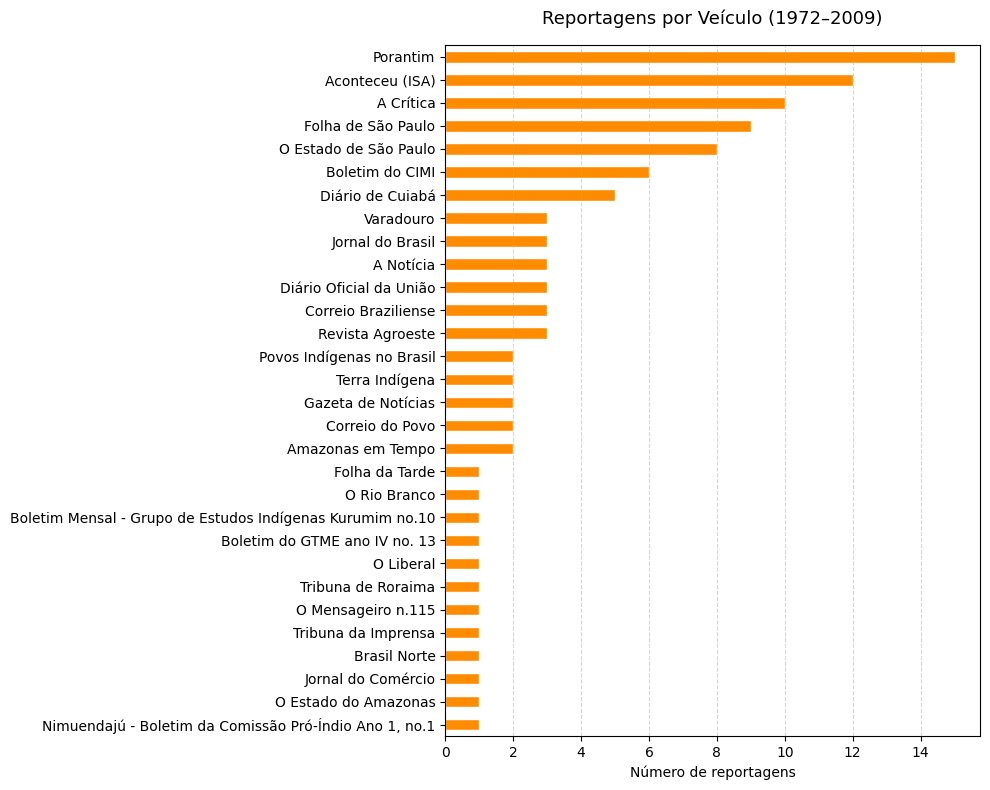

In [63]:
# Cobertura por veículo — ranking geral

contagem_veiculo = df_rep['Nome do Jornal ou Revista'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
contagem_veiculo.plot(kind='barh', color='darkorange', edgecolor='white')

plt.title('Reportagens por Veículo (1972–2009)', fontsize=13, pad=15)
plt.xlabel('Número de reportagens')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../outputs/figures/15_ranking_veiculos.png', dpi=300)
plt.show()

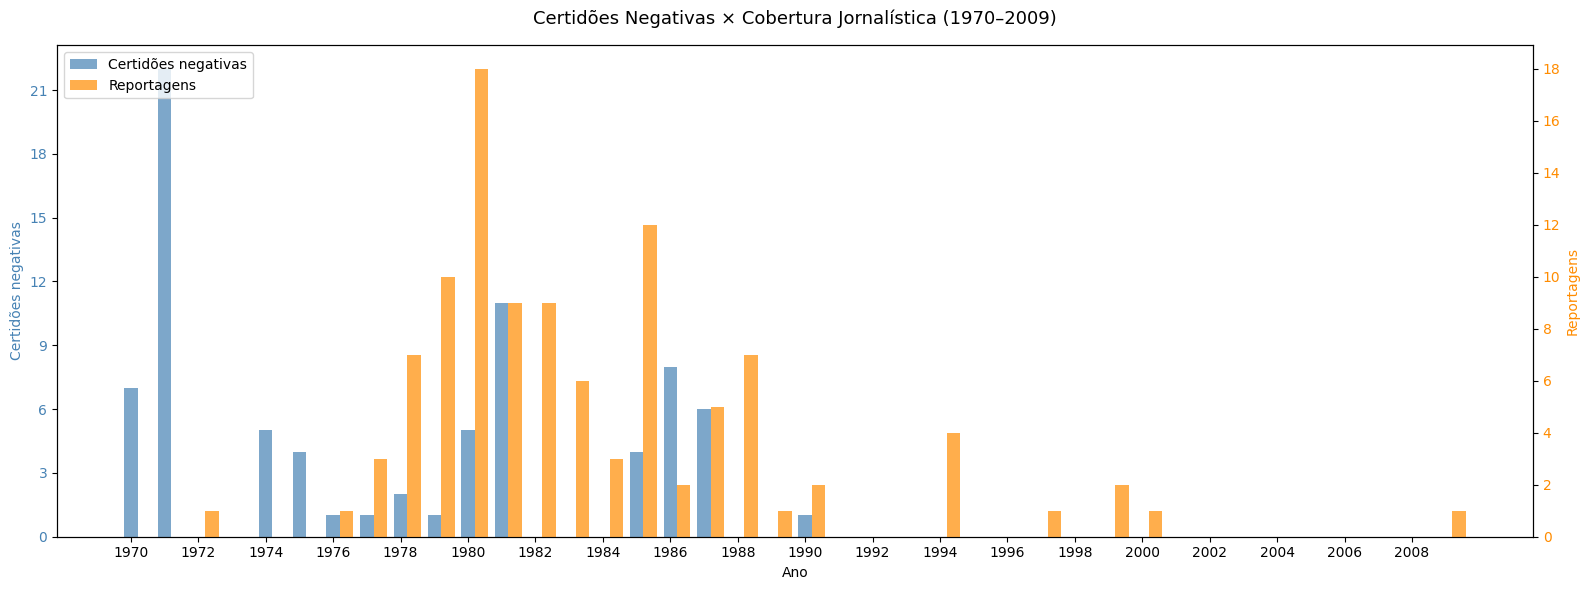

In [65]:
# Certidões × Reportagens no mesmo eixo temporal

freq_cert = df_cert['Ano'].value_counts().sort_index()
freq_rep = df_rep['Ano'].value_counts().sort_index()

# Alinhar os dois índices
todos_anos = range(min(freq_cert.index.min(), freq_rep.index.min()),
                   max(freq_cert.index.max(), freq_rep.index.max()) + 1)

freq_cert = freq_cert.reindex(todos_anos, fill_value=0)
freq_rep = freq_rep.reindex(todos_anos, fill_value=0)

fig, ax1 = plt.subplots(figsize=(16, 6))

# Eixo esquerdo — certidões
ax1.bar(freq_cert.index, freq_cert.values, color='steelblue', alpha=0.7,
        label='Certidões negativas', width=0.4, align='center')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Certidões negativas', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Eixo direito — reportagens
ax2 = ax1.twinx()
ax2.bar(freq_rep.index + 0.4, freq_rep.values, color='darkorange', alpha=0.7,
        label='Reportagens', width=0.4, align='center')
ax2.set_ylabel('Reportagens', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Título e eixo X
plt.title('Certidões Negativas × Cobertura Jornalística (1970–2009)',
          fontsize=13, pad=15)
plt.xticks(range(min(todos_anos), max(todos_anos) + 1, 2), rotation=45)

# Legenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/16_certidoes_x_reportagens.png', dpi=300)
plt.show()